In [48]:
import sys, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d  
import scipy
import pickle 
import uproot
print(uproot.__version__)

5.1.2


In [49]:
## -------------------------------- ##
##        SET PLOTTING STYLE        ##
## -------------------------------- ##
matplotlib.rcParams['figure.figsize'] = 8.5,6
matplotlib.rcParams['figure.subplot.left'] = 0.15
matplotlib.rcParams['figure.subplot.right'] = 0.88
matplotlib.rcParams['figure.subplot.bottom'] = 0.15
matplotlib.rcParams['figure.subplot.top'] = 0.88
matplotlib.rcParams['axes.titlesize'] = 20
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.labelweight'] = 'normal'
matplotlib.rcParams['font.weight'] = 'normal' 
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['lines.linewidth'] = 2
matplotlib.rcParams['lines.markersize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 16
matplotlib.rcParams['ytick.labelsize'] = 16
matplotlib.rcParams['xtick.major.size'] = 8
matplotlib.rcParams['ytick.major.size'] = 8
matplotlib.rcParams['xtick.minor.size'] = 4
matplotlib.rcParams['ytick.minor.size'] = 4
matplotlib.rcParams['xtick.minor.visible'] = True 
matplotlib.rcParams['ytick.minor.visible'] = True
matplotlib.rcParams['xtick.direction'] = 'in' 
matplotlib.rcParams['ytick.direction'] = 'in' 
matplotlib.rcParams['xtick.top'] = True 
matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['xtick.major.pad'] = 6
matplotlib.rcParams['image.cmap'] = 'viridis'

In [72]:
## Open file
file = uproot.open('../Geant4_Sim/output/Spectrum_neutron_0.1He_Point0phi_90theta.root')

## Only one tree in each file
tree = file['Events']
print(list(tree.keys()))

## Get branches of interest
prim_energy_KeV = np.array(tree['primaries.energy_keV'])
track_detName = np.array(tree['tracks.detectorName'])
track_energyDep_keV = np.array(tree['tracks.energyDeposition_keV'])
track_time_ns = np.array(tree['tracks.stepTime_ns'])
track_x_cm = np.array(tree['tracks.x_global_um'])*1e-4
track_y_cm = np.array(tree['tracks.y_global_um'])*1e-4
track_z_cm = np.array(tree['tracks.z_global_um'])*1e-4

nEvents = len(prim_energy_KeV)
print(f'{nEvents} primaries were simulated!')

['primaries.particleName', 'primaries.volumeName', 'primaries.time_ns', 'primaries.energy_keV', 'primaries.totalEnergy_keV', 'primaries.totalMomentum_keV', 'primaries.position_X_mm', 'primaries.position_Y_mm', 'primaries.position_Z_mm', 'primaries.direction_X', 'primaries.direction_Y', 'primaries.direction_Z', 'tracks.trackID', 'tracks.stepNumber', 'tracks.parentID', 'tracks.detectorName', 'tracks.particleName', 'tracks.creationProcess', 'tracks.particleMass_keV', 'tracks.stepTime_ns', 'tracks.preStepEnergy_keV', 'tracks.energyDeposition_keV', 'tracks.stepLength_um', 'tracks.preStepMomentumX_keV', 'tracks.preStepMomentumY_keV', 'tracks.preStepMomentumZ_keV', 'tracks.x_global_um', 'tracks.y_global_um', 'tracks.z_global_um']
1000000 primaries were simulated!


# Primary Neutron Spectra

[4998.7344   898.25836 1484.8273  ... 2756.3281  3210.1763  4144.764  ]


Text(0, 0.5, 'Counts')

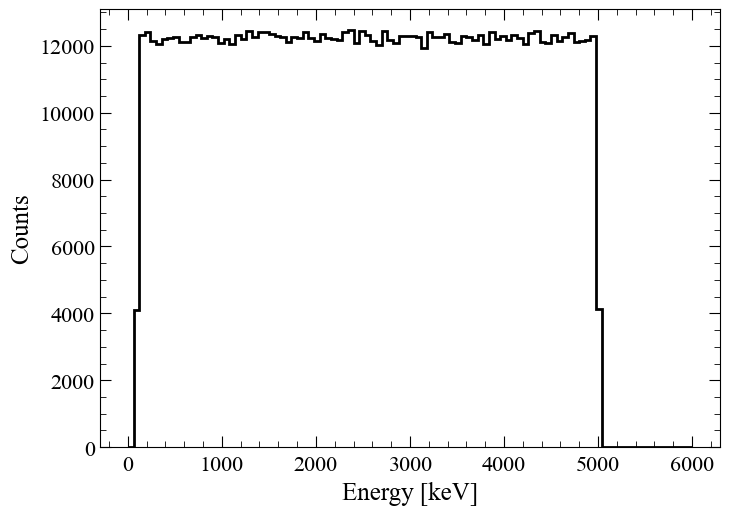

In [73]:
print(np.concatenate(prim_energy_KeV))

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(np.concatenate(prim_energy_KeV), bins=100, range=[0,6000], histtype='step', lw=2, color='black')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Counts')

## Energy Deposited in TPC and Liquid Scint Detectors. Calculate T.o.F.

In [74]:
## Energy deposited in each detector
EdepkeV_dict = {'TPC':np.zeros(nEvents), 'PTFE':np.zeros(nEvents), 'ICV':np.zeros(nEvents), 'OCV':np.zeros(nEvents),
                'LiqScintDet0deg':np.zeros(nEvents), 'LiqScintDet15deg':np.zeros(nEvents), 'LiqScintDet30deg':np.zeros(nEvents),
                'LiqScintDet45deg':np.zeros(nEvents), 'LiqScintDet60deg':np.zeros(nEvents), 'LiqScintDet75deg':np.zeros(nEvents),
                'LiqScintDet90deg':np.zeros(nEvents), 'LiqScintDet105deg':np.zeros(nEvents), 'LiqScintDet120deg':np.zeros(nEvents),
                'LiqScintDet135deg':np.zeros(nEvents), 'LiqScintDet150deg':np.zeros(nEvents), 'LiqScintDet165deg':np.zeros(nEvents),
                }
## position of recoil in TPC and liquid scintillator
pos_TPC_cm = np.zeros((nEvents,3))
pos_liqScint_cm = np.zeros((nEvents,3))
## time of recoil in TPC and liquid scint for time-of-flight
time_TPC_ns = np.zeros(nEvents)
time_liqScint_ns = np.zeros(nEvents)
## depends on liquid scintillator detector hit
recoilAngle_deg = np.zeros(nEvents)

## Loop Through Events
for idx in range(nEvents):
    
    if idx % 10000 == 0:
        print(f'On Event {idx}/{nEvents}')

    ## Loop through steps in tracks
    for jdx in range(len(track_detName[idx])):

        t_detName = track_detName[idx][jdx]
        t_Edep = track_energyDep_keV[idx][jdx]
        t_time_ns = track_time_ns[idx][jdx]
        t_x_cm = track_x_cm[idx][jdx]
        t_y_cm = track_y_cm[idx][jdx]
        t_z_cm = track_z_cm[idx][jdx]

        ## Energy deposit in each detector
        EdepkeV_dict[t_detName][idx] += t_Edep

        ## deposits in TPC
        if t_detName == 'TPC':
           time_TPC_ns[idx] += t_time_ns
           pos_TPC_cm[idx] = [t_x_cm, t_y_cm, t_z_cm]

        ## Hits on backing detector
        if (t_detName.find('LiqScintDet') != -1) and (time_liqScint_ns[idx] == 0):
            time_liqScint_ns[idx] = t_time_ns
            pos_liqScint_cm[idx] = [t_x_cm, t_y_cm, t_z_cm]
            
            angle = float(t_detName[len('LiqScintDet'):-len('deg')])
            recoilAngle_deg[idx] = angle
            
            break

print('Done')
    

On Event 0/1000000
On Event 10000/1000000
On Event 20000/1000000
On Event 30000/1000000
On Event 40000/1000000
On Event 50000/1000000
On Event 60000/1000000
On Event 70000/1000000
On Event 80000/1000000
On Event 90000/1000000
On Event 100000/1000000
On Event 110000/1000000
On Event 120000/1000000
On Event 130000/1000000
On Event 140000/1000000
On Event 150000/1000000
On Event 160000/1000000
On Event 170000/1000000
On Event 180000/1000000
On Event 190000/1000000
On Event 200000/1000000
On Event 210000/1000000
On Event 220000/1000000
On Event 230000/1000000
On Event 240000/1000000
On Event 250000/1000000
On Event 260000/1000000
On Event 270000/1000000
On Event 280000/1000000
On Event 290000/1000000
On Event 300000/1000000
On Event 310000/1000000
On Event 320000/1000000
On Event 330000/1000000
On Event 340000/1000000
On Event 350000/1000000
On Event 360000/1000000
On Event 370000/1000000
On Event 380000/1000000
On Event 390000/1000000
On Event 400000/1000000
On Event 410000/1000000
On Eve

# Plotting

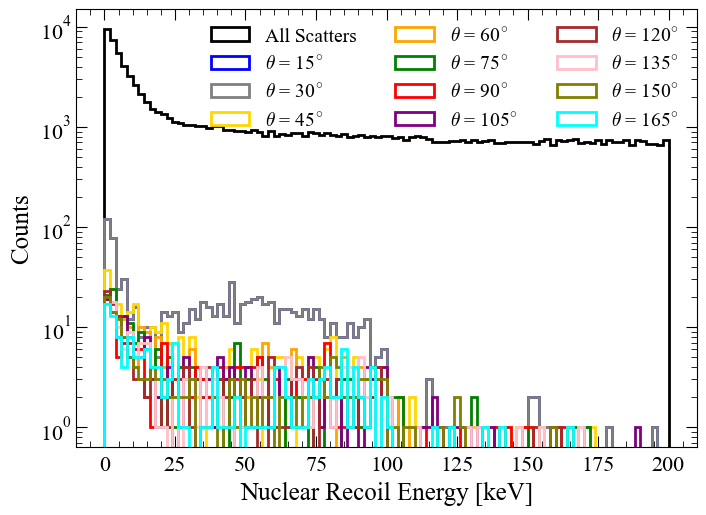

In [78]:
## Mask For Recoil Angle
mask_0deg = np.where(recoilAngle_deg==0., True, False)
mask_15deg = np.where(recoilAngle_deg==15., True, False)
mask_30deg = np.where(recoilAngle_deg==30., True, False)
mask_45deg = np.where(recoilAngle_deg==45., True, False)
mask_60deg = np.where(recoilAngle_deg==60., True, False)
mask_75deg = np.where(recoilAngle_deg==75., True, False)
mask_90deg = np.where(recoilAngle_deg==90., True, False)
mask_105deg = np.where(recoilAngle_deg==105., True, False)
mask_120deg = np.where(recoilAngle_deg==120., True, False)
mask_135deg = np.where(recoilAngle_deg==135., True, False)
mask_150deg = np.where(recoilAngle_deg==150., True, False)
mask_165deg = np.where(recoilAngle_deg==165., True, False)

## Mask for Edep > 0. in TPC
mask_Edep_tpc = EdepkeV_dict['TPC'] > 0.


## Plot
colors = ['gold','blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc], bins=100, range=[0,200], lw=2, histtype='step', color='black', label='All Scatters')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_15deg], bins=100, range=[0,200], lw=2, histtype='step', color='blue', label=r'$\theta$ = 15$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_15deg], bins=100, range=[0,200], lw=2, histtype='step', color='gray', label=r'$\theta$ = 30$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_45deg], bins=100, range=[0,200], lw=2, histtype='step', color='gold', label=r'$\theta$ = 45$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_60deg], bins=100, range=[0,200], lw=2, histtype='step', color='orange', label=r'$\theta$ = 60$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_75deg], bins=100, range=[0,200], lw=2, histtype='step', color='green', label=r'$\theta$ = 75$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_90deg], bins=100, range=[0,200], lw=2, histtype='step', color='red', label=r'$\theta$ = 90$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_105deg], bins=100, range=[0,200], lw=2, histtype='step', color='purple', label=r'$\theta$ = 105$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_120deg], bins=100, range=[0,200], lw=2, histtype='step', color='brown', label=r'$\theta$ = 120$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_135deg], bins=100, range=[0,200], lw=2, histtype='step', color='pink', label=r'$\theta$ = 135$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_150deg], bins=100, range=[0,200], lw=2, histtype='step', color='olive', label=r'$\theta$ = 150$^{\circ}$')
ax.hist(EdepkeV_dict['TPC'][mask_Edep_tpc&mask_165deg], bins=100, range=[0,200], lw=2, histtype='step', color='cyan', label=r'$\theta$ = 165$^{\circ}$')


ax.set_xlabel('Nuclear Recoil Energy [keV]')
ax.set_ylabel('Counts')
ax.set_yscale('log')
ax.legend(frameon=False, loc='upper right', fontsize=14, ncol=3)


Text(0.5, 0, 'Time of Flight [ns]')

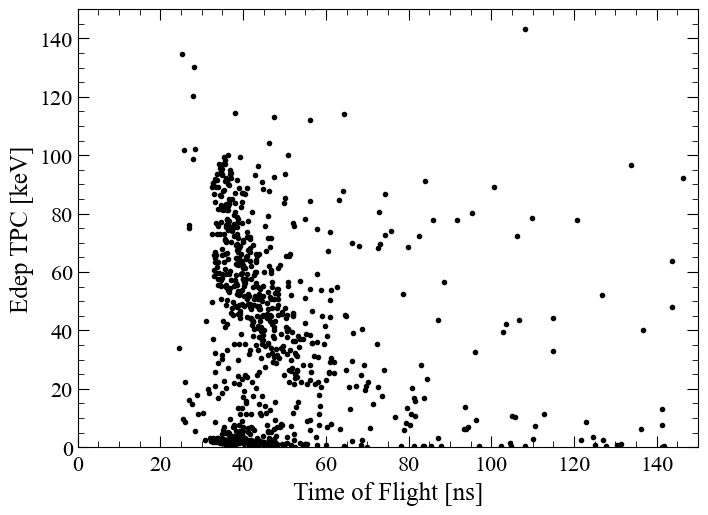

In [86]:
timeOfFlight_ns = time_liqScint_ns - time_TPC_ns

fig, ax = plt.subplots(1,1,dpi=100)

ax.plot(timeOfFlight_ns[mask_Edep_tpc&mask_15deg], EdepkeV_dict['TPC'][mask_Edep_tpc&mask_15deg], 
        'o', color='black', markersize=3)

ax.set_ylim(0,150)
ax.set_xlim(0,150)
ax.set_ylabel('Edep TPC [keV]')
ax.set_xlabel('Time of Flight [ns]')